In [428]:
import sys, os
import glob
import json
import random
from typing import List, Dict
from dataclasses import dataclass, field
from pathlib import Path

import torch
torch.set_default_dtype(torch.float64)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import openmm.app as app

sys.path.insert(0, '..')
from cmm.forcefield import CMMForceField
from cmm.units import HARTREE2KCAL, BOHR2ANG, BOHR2NM
from cmm.develop.data import EdaData2
from cmm.develop.optimize import Trainer2, Optimizer
from cmm.develop.metrics import plot_correlation, plot_eda_scan
from cmm.develop.extract_params import extract_bond_angle_eq, extract_multipoles

### Load Data

In [429]:
data_path = os.path.join("/home/heindelj/research/Teresa/reactive_force_fields/reference_data/CMM_Data/ion_water")

In [430]:
f_water_test_pdb = os.path.join(data_path, "train_test_splits/f_water_wb97xv_qzvppd_test.pdb")
f_water_test_csv = os.path.join(data_path, "train_test_splits/f_water_wb97xv_qzvppd_test.csv")

cl_water_test_pdb = os.path.join(data_path, "train_test_splits/cl_water_wb97xv_qzvppd_test.pdb")
cl_water_test_csv = os.path.join(data_path, "train_test_splits/cl_water_wb97xv_qzvppd_test.csv")

br_water_test_pdb = os.path.join(data_path, "train_test_splits/br_water_wb97xv_qzvppd_test.pdb")
br_water_test_csv = os.path.join(data_path, "train_test_splits/br_water_wb97xv_qzvppd_test.csv")

i_water_test_pdb = os.path.join(data_path, "train_test_splits/i_water_wb97xv_qzvppd_test.pdb")
i_water_test_csv = os.path.join(data_path, "train_test_splits/i_water_wb97xv_qzvppd_test.csv")

li_water_test_pdb = os.path.join(data_path, "train_test_splits/li_water_wb97xv_qzvppd_test.pdb")
li_water_test_csv = os.path.join(data_path, "train_test_splits/li_water_wb97xv_qzvppd_test.csv")

na_water_test_pdb = os.path.join(data_path, "train_test_splits/na_water_wb97xv_qzvppd_test.pdb")
na_water_test_csv = os.path.join(data_path, "train_test_splits/na_water_wb97xv_qzvppd_test.csv")

k_water_test_pdb = os.path.join(data_path, "train_test_splits/k_water_wb97xv_qzvppd_test.pdb")
k_water_test_csv = os.path.join(data_path, "train_test_splits/k_water_wb97xv_qzvppd_test.csv")

rb_water_test_pdb = os.path.join(data_path, "train_test_splits/rb_water_wb97xv_qzvppd_test.pdb")
rb_water_test_csv = os.path.join(data_path, "train_test_splits/rb_water_wb97xv_qzvppd_test.csv")

cs_water_test_pdb = os.path.join(data_path, "train_test_splits/cs_water_wb97xv_qzvppd_test.pdb")
cs_water_test_csv = os.path.join(data_path, "train_test_splits/cs_water_wb97xv_qzvppd_test.csv")

mg_water_test_pdb = os.path.join(data_path, "train_test_splits/mg_water_wb97xv_qzvppd_test.pdb")
mg_water_test_csv = os.path.join(data_path, "train_test_splits/mg_water_wb97xv_qzvppd_test.csv")

ca_water_test_pdb = os.path.join(data_path, "train_test_splits/ca_water_wb97xv_qzvppd_test.pdb")
ca_water_test_csv = os.path.join(data_path, "train_test_splits/ca_water_wb97xv_qzvppd_test.csv")

In [431]:
f_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_f_scan.pdb")
f_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_f_scan.csv")

cl_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_cl_scan.pdb")
cl_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_cl_scan.csv")

br_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_br_scan.pdb")
br_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_br_scan.csv")

i_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_i_scan.pdb")
i_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_i_scan.csv")

li_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_li_scan.pdb")
li_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_li_scan.csv")

na_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_na_scan.pdb")
na_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_na_scan.csv")

k_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_k_scan.pdb")
k_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_k_scan.csv")

rb_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_rb_scan.pdb")
rb_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_rb_scan.csv")

cs_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_cs_scan.pdb")
cs_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_cs_scan.csv")

mg_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_mg_scan.pdb")
mg_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_mg_scan.csv")

ca_water_scan_pdb = os.path.join(data_path, "ion_water_scans/h2o_ca_scan.pdb")
ca_water_scan_csv = os.path.join(data_path, "ion_water_scans/h2o_ca_scan.csv")

In [432]:
na_cl_scan_pdb = os.path.join(data_path, "ion_ion_scans/na_cl_scan.pdb")
na_cl_scan_csv = os.path.join(data_path, "ion_ion_scans/na_cl_scan.csv")

In [447]:
#f_water_test_data = EdaData2.from_csv_file(f_water_test_pdb, f_water_test_csv, num_samples=1000)
#cl_water_test_data = EdaData2.from_csv_file(cl_water_test_pdb, cl_water_test_csv, num_samples=1000)
#br_water_test_data = EdaData2.from_csv_file(br_water_test_pdb, br_water_test_csv, num_samples=1000)
#i_water_test_data = EdaData2.from_csv_file(i_water_test_pdb, i_water_test_csv, num_samples=1000)
#
#li_water_test_data = EdaData2.from_csv_file(li_water_test_pdb, li_water_test_csv, num_samples=1000)
#na_water_test_data = EdaData2.from_csv_file(na_water_test_pdb, na_water_test_csv, num_samples=1000)
#k_water_test_data = EdaData2.from_csv_file(k_water_test_pdb, k_water_test_csv, num_samples=1000)
#rb_water_test_data = EdaData2.from_csv_file(rb_water_test_pdb, rb_water_test_csv, num_samples=1000)
#cs_water_test_data = EdaData2.from_csv_file(cs_water_test_pdb, cs_water_test_csv, num_samples=1000)
#
#mg_water_test_data = EdaData2.from_csv_file(mg_water_test_pdb, mg_water_test_csv, num_samples=1000)
#ca_water_test_data = EdaData2.from_csv_file(ca_water_test_pdb, ca_water_test_csv, num_samples=1000)

In [434]:
f_water_scan_data = EdaData2.from_csv_file(f_water_scan_pdb, f_water_scan_csv)
cl_water_scan_data = EdaData2.from_csv_file(cl_water_scan_pdb, cl_water_scan_csv)
br_water_scan_data = EdaData2.from_csv_file(br_water_scan_pdb, br_water_scan_csv)
i_water_scan_data = EdaData2.from_csv_file(i_water_scan_pdb, i_water_scan_csv)

li_water_scan_data = EdaData2.from_csv_file(li_water_scan_pdb, li_water_scan_csv)
na_water_scan_data = EdaData2.from_csv_file(na_water_scan_pdb, na_water_scan_csv)
k_water_scan_data = EdaData2.from_csv_file(k_water_scan_pdb, k_water_scan_csv)
rb_water_scan_data = EdaData2.from_csv_file(rb_water_scan_pdb, rb_water_scan_csv)
cs_water_scan_data = EdaData2.from_csv_file(cs_water_scan_pdb, cs_water_scan_csv)

mg_water_scan_data = EdaData2.from_csv_file(mg_water_scan_pdb, mg_water_scan_csv)
ca_water_scan_data = EdaData2.from_csv_file(ca_water_scan_pdb, ca_water_scan_csv)

In [435]:
na_cl_scan_data = EdaData2.from_csv_file(na_cl_scan_pdb, na_cl_scan_csv)

### Create Force Field

In [436]:
ff = CMMForceField(os.path.join(os.path.abspath(''), "../tests/data/ion_water_params_8_27.json"))

optimizer = Optimizer(
    ff
)

trainer = Trainer2(
    ff, optimizer
)

### Plotting Functions

In [437]:
def report_eda_cluster(trainer, data, **kwargs):
    with torch.no_grad():
        res, ref = trainer.evaluate(data)
    
    keys = ['total', 'perm_elec', 'pol', 'ct', 'pauli', 'disp']
    fig, axes = plt.subplots(2, 3, figsize=(9, 6), constrained_layout=True)
    axes = axes.flatten()
    for i in range(len(keys)):
        ax = axes[i]
        key = keys[i]
        if key == 'total':
            plot_correlation(ref['int'], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        else:
            plot_correlation(ref[key], res[key], xlabel='QM (kcal/mol)', ylabel='CMM (kcal/mol)', ax=ax)
        ax.set_title(key.upper())
    return fig

def report_eda_scan(trainer, data, **kwargs):
    with torch.no_grad():
        res, ref = trainer.evaluate(data)
    
    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes = axes.flatten()
    if 'distances' in data.eda_df:
        xdata = data.eda_df['distances'].to_numpy()
        xlabel = "Distance (A)"
    else:
        xdata=np.linspace(1, len(ref['int']), len(ref['int']), dtype=np.int64)
        xlabel = "k_index"
    keys = ['perm_elec', 'pauli', 'disp', 'pol', 'ct', 'total']
    print(res['pol'])
    plot_eda_scan(xdata, {'total': ref['int']}, {'total': res['total']}, ax=axes[0], keys=['total'], xmax=5, ymax=0, xlabel=xlabel)
    
    ref['total'] = ref['int']
    with torch.no_grad():
        error = {key: res[key] - ref[key] for key in keys}
    plot_eda_scan(xdata, error, ylabel='Energy Error (kcal/mol)', ax=axes[1], xmax=5, xlabel=xlabel, ymin=-1, ymax=1)
    return fig

tensor([-62.2442, -36.5797, -25.9607, -21.7580, -18.9097, -16.1496, -13.6333,
        -11.4512,  -9.6037,  -8.0669,  -6.7820,  -5.7239,  -4.8468,  -4.1201,
         -3.5255,  -3.0266,  -2.6146,  -2.2711,  -1.9803,  -1.7380,  -1.5312,
         -1.3532,  -1.2026,  -1.0721,  -0.9606,  -0.8627,  -0.7766,  -0.7025,
         -0.6365,  -0.5787,  -0.5273,  -0.4813,  -0.4409,  -0.4042,  -0.3715,
         -0.3423,  -0.3154,  -0.2915,  -0.2697,  -0.2500,  -0.2323,  -0.2158,
         -0.2010,  -0.1873,  -0.1748,  -0.1635,  -0.1529,  -0.1432,  -0.1344,
         -0.1261,  -0.1185])


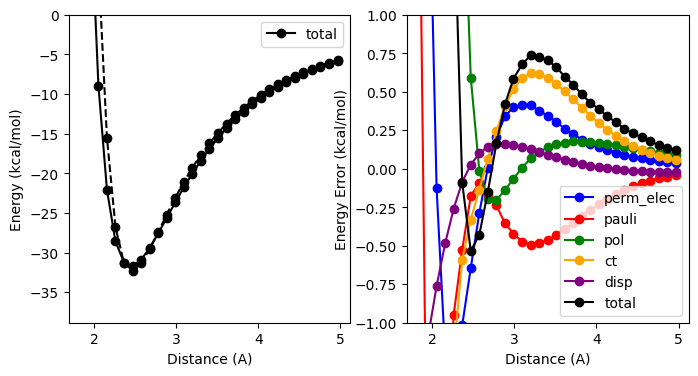

In [438]:
f_water_scan_fig = report_eda_scan(trainer, f_water_scan_data)

tensor([-1.3367, -2.8244, -3.7514, -4.1831, -4.2563, -4.1039, -3.8191, -3.4691,
        -3.1126, -2.7642, -2.4470, -2.1577, -1.9038, -1.6774, -1.4856, -1.3162,
        -1.1690, -1.0426, -0.9317, -0.8364, -0.7517, -0.6785, -0.6140, -0.5576,
        -0.5065, -0.4616, -0.4222, -0.3865, -0.3548, -0.3262, -0.3006, -0.2776,
        -0.2568, -0.2378, -0.2206, -0.2049, -0.1907, -0.1777, -0.1657, -0.1548,
        -0.1448, -0.1356, -0.1271, -0.1193, -0.1121, -0.1053, -0.0992, -0.0934,
        -0.0881, -0.0832, -0.0786])


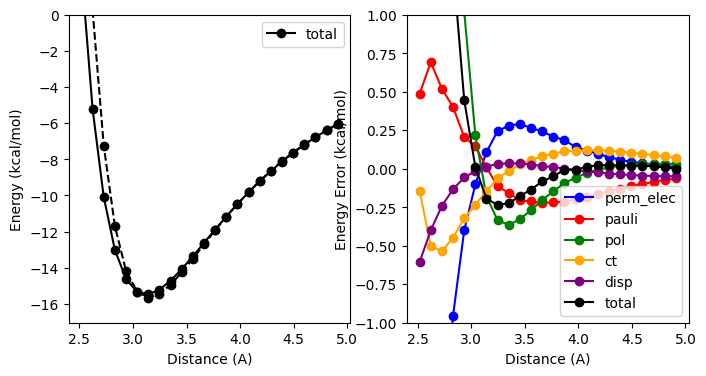

In [439]:
cl_water_scan_fig = report_eda_scan(trainer, cl_water_scan_data)

tensor([-2.1820, -2.2710, -2.6530, -2.9426, -3.0536, -3.0099, -2.8576, -2.6493,
        -2.4128, -2.1753, -1.9456, -1.7335, -1.5450, -1.3735, -1.2244, -1.0926,
        -0.9780, -0.8756, -0.7872, -0.7094, -0.6406, -0.5807, -0.5273, -0.4804,
        -0.4380, -0.4007, -0.3673, -0.3370, -0.3105, -0.2863, -0.2644, -0.2445,
        -0.2268, -0.2103, -0.1955, -0.1821, -0.1697, -0.1584, -0.1480, -0.1385,
        -0.1297, -0.1216, -0.1143, -0.1073, -0.1010, -0.0951, -0.0896, -0.0846,
        -0.0798, -0.0755, -0.0714])


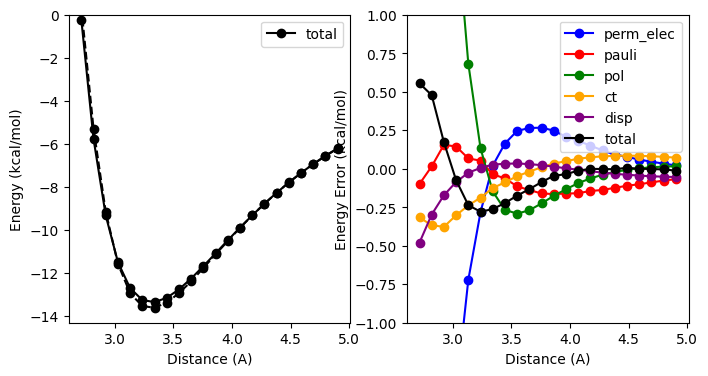

In [440]:
br_water_scan_fig = report_eda_scan(trainer, br_water_scan_data)

tensor([ 0.1401, -1.1170, -1.8939, -2.2888, -2.4244, -2.3992, -2.2778, -2.1104,
        -1.9250, -1.7380, -1.5621, -1.3978, -1.2504, -1.1179, -1.0008, -0.8982,
        -0.8069, -0.7266, -0.6561, -0.5936, -0.5386, -0.4896, -0.4464, -0.4078,
        -0.3733, -0.3425, -0.3148, -0.2899, -0.2674, -0.2472, -0.2288, -0.2123,
        -0.1973, -0.1835, -0.1709, -0.1593, -0.1489, -0.1392, -0.1303, -0.1222,
        -0.1146, -0.1076, -0.1012, -0.0953, -0.0898, -0.0846, -0.0799, -0.0755,
        -0.0714, -0.0675, -0.0639])


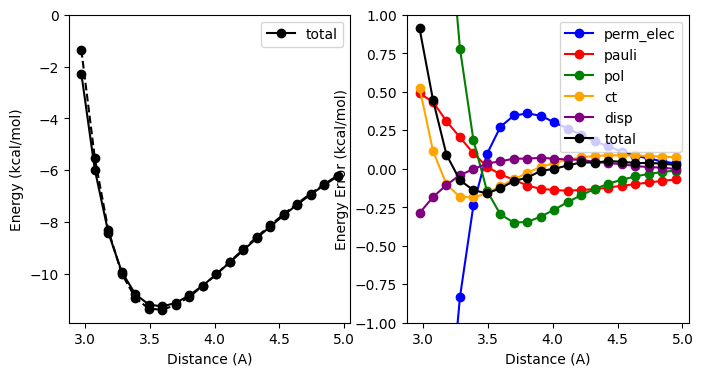

In [441]:
i_water_scan_fig = report_eda_scan(trainer, i_water_scan_data)

tensor([ 25.9079,   5.5477,  -4.7976,  -9.4400, -11.0005, -10.9733, -10.2203,
         -9.1541,  -8.0359,  -6.9780,  -6.0254,  -5.1875,  -4.4691,  -3.8670,
         -3.3456,  -2.9065,  -2.5396,  -2.2254,  -1.9559,  -1.7255,  -1.5305,
         -1.3613,  -1.2136,  -1.0857,  -0.9750,  -0.8773,  -0.7914,  -0.7165,
         -0.6508,  -0.5916,  -0.5392,  -0.4930,  -0.4510,  -0.4132,  -0.3797,
         -0.3496,  -0.3222,  -0.2976,  -0.2755,  -0.2551,  -0.2365,  -0.2198,
         -0.2046,  -0.1905,  -0.1776,  -0.1659,  -0.1551,  -0.1450,  -0.1358,
         -0.1275,  -0.1198])


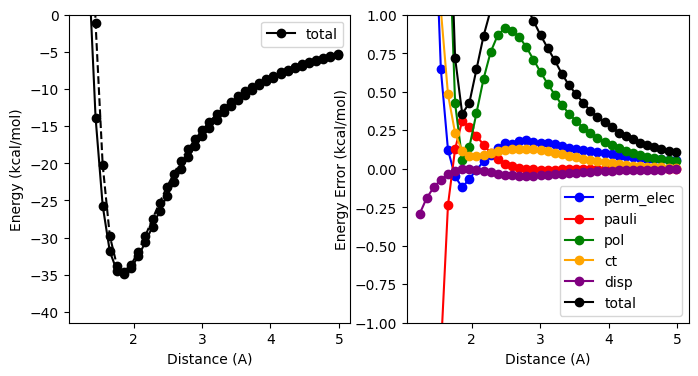

In [442]:
li_water_scan_fig = report_eda_scan(trainer, li_water_scan_data)

tensor([ 0.8060, -4.3914, -6.6361, -7.2927, -7.1376, -6.5949, -5.9244, -5.2294,
        -4.5748, -3.9937, -3.4750, -3.0279, -2.6467, -2.3204, -2.0403, -1.8001,
        -1.5919, -1.4131, -1.2603, -1.1271, -1.0103, -0.9075, -0.8188, -0.7404,
        -0.6709, -0.6095, -0.5550, -0.5067, -0.4632, -0.4246, -0.3901, -0.3589,
        -0.3306, -0.3051, -0.2819, -0.2612, -0.2423, -0.2247, -0.2090, -0.1947,
        -0.1815, -0.1694, -0.1583, -0.1480, -0.1387, -0.1301, -0.1221, -0.1147,
        -0.1078, -0.1015, -0.0956])


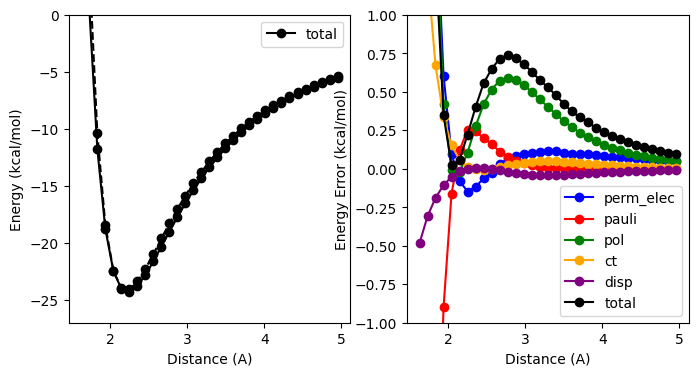

In [443]:
na_water_scan_fig = report_eda_scan(trainer, na_water_scan_data)

tensor([-6.9265, -6.5841, -6.0374, -5.4238, -4.8077, -4.2248, -3.7000, -3.2309,
        -2.8249, -2.4751, -2.1747, -1.9140, -1.6907, -1.4950, -1.3295, -1.1856,
        -1.0604, -0.9519, -0.8567, -0.7717, -0.6989, -0.6340, -0.5764, -0.5255,
        -0.4803, -0.4389, -0.4027, -0.3701, -0.3406, -0.3142, -0.2900, -0.2681,
        -0.2485, -0.2306, -0.2142, -0.1994, -0.1857, -0.1731, -0.1617, -0.1512,
        -0.1415, -0.1327, -0.1245, -0.1168, -0.1098, -0.1034, -0.0974, -0.0918,
        -0.0866, -0.0817, -0.0772])


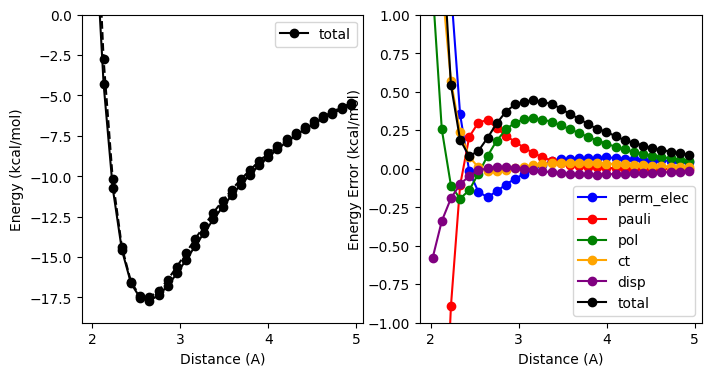

In [444]:
k_water_scan_fig = report_eda_scan(trainer, k_water_scan_data)

tensor([-6.6816, -5.9317, -5.2141, -4.5612, -3.9808, -3.4674, -3.0204, -2.6329,
        -2.3057, -2.0244, -1.7819, -1.5750, -1.3948, -1.2416, -1.1086, -0.9923,
        -0.8910, -0.8029, -0.7249, -0.6569, -0.5962, -0.5425, -0.4950, -0.4528,
        -0.4146, -0.3802, -0.3498, -0.3222, -0.2976, -0.2752, -0.2545, -0.2360,
        -0.2191, -0.2039, -0.1899, -0.1768, -0.1650, -0.1542, -0.1444, -0.1353,
        -0.1268, -0.1190, -0.1117, -0.1052, -0.0990, -0.0933, -0.0880, -0.0831,
        -0.0785, -0.0742, -0.0702])


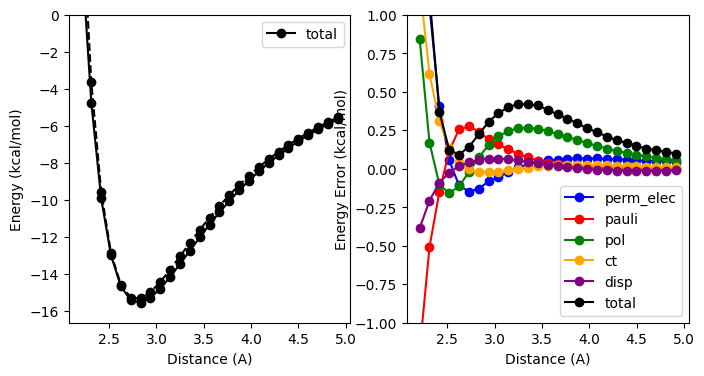

In [445]:
rb_water_scan_fig = report_eda_scan(trainer, rb_water_scan_data)

tensor([-9.1472, -7.1851, -5.7579, -4.7063, -3.8917, -3.2637, -2.7703, -2.3727,
        -2.0492, -1.7844, -1.5625, -1.3754, -1.2184, -1.0832, -0.9684, -0.8672,
        -0.7797, -0.7037, -0.6368, -0.5779, -0.5257, -0.4793, -0.4382, -0.4013,
        -0.3683, -0.3388, -0.3121, -0.2877, -0.2663, -0.2465, -0.2285, -0.2123,
        -0.1973, -0.1839, -0.1714, -0.1600, -0.1498, -0.1401, -0.1312, -0.1232,
        -0.1156, -0.1087, -0.1022, -0.0962, -0.0907, -0.0856, -0.0808, -0.0764,
        -0.0721, -0.0683, -0.0647])
Error in callback <function _draw_all_if_interactive at 0x7f57863c28e0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

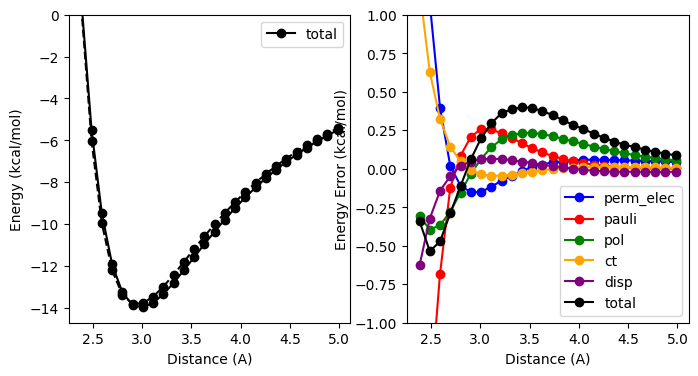

In [446]:
cs_water_scan_fig = report_eda_scan(trainer, cs_water_scan_data)

tensor([ 17.9446, -19.0631, -37.2610, -44.1972, -44.8585, -42.3178, -38.2775,
        -33.7930, -29.4776, -25.5156, -22.0424, -18.9527, -16.3791, -14.1737,
        -12.3007, -10.7180,  -9.3539,  -8.2181,  -7.2360,  -6.3998,  -5.6822,
         -5.0528,  -4.5169,  -4.0491,  -3.6428,  -3.2834,  -2.9673,  -2.6903,
         -2.4445,  -2.2287,  -2.0317,  -1.8590,  -1.7041,  -1.5650,  -1.4401,
         -1.3256,  -1.2239,  -1.1310,  -1.0481,  -0.9722,  -0.9019,  -0.8387,
         -0.7810,  -0.7287,  -0.6800,  -0.6353,  -0.5945,  -0.5568,  -0.5223,
         -0.4900,  -0.4605])


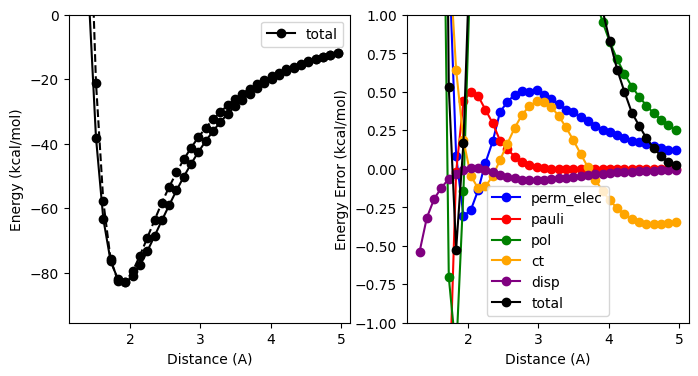

In [ ]:
mg_water_scan_fig = report_eda_scan(trainer, mg_water_scan_data)

tensor([-49.7554, -42.7165, -37.3493, -32.8459, -28.9278, -25.5260, -22.4482,
        -19.7058, -17.3098, -15.2145, -13.3456, -11.7309, -10.3311,  -9.1110,
         -8.0466,  -7.1288,  -6.3454,  -5.6461,  -5.0415,  -4.5163,  -4.0542,
         -3.6486,  -3.2919,  -2.9812,  -2.7023,  -2.4556,  -2.2363,  -2.0423,
         -1.8671,  -1.7102,  -1.5727,  -1.4459,  -1.3314,  -1.2287,  -1.1361,
         -1.0516,  -0.9746,  -0.9061,  -0.8422,  -0.7837,  -0.7308,  -0.6822,
         -0.6371,  -0.5960,  -0.5589,  -0.5236,  -0.4915,  -0.4617,  -0.4342,
         -0.4084,  -0.3848])


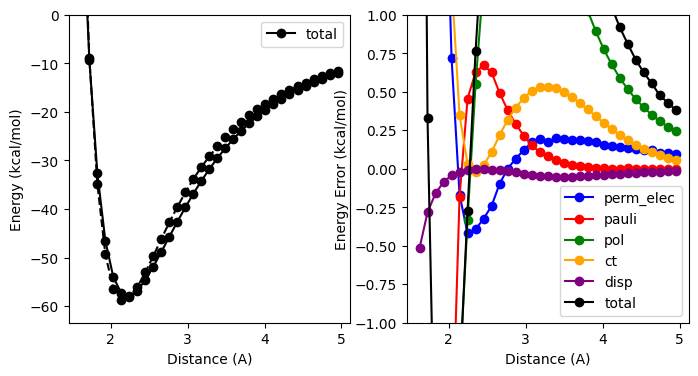

In [ ]:
ca_water_scan_fig = report_eda_scan(trainer, ca_water_scan_data)

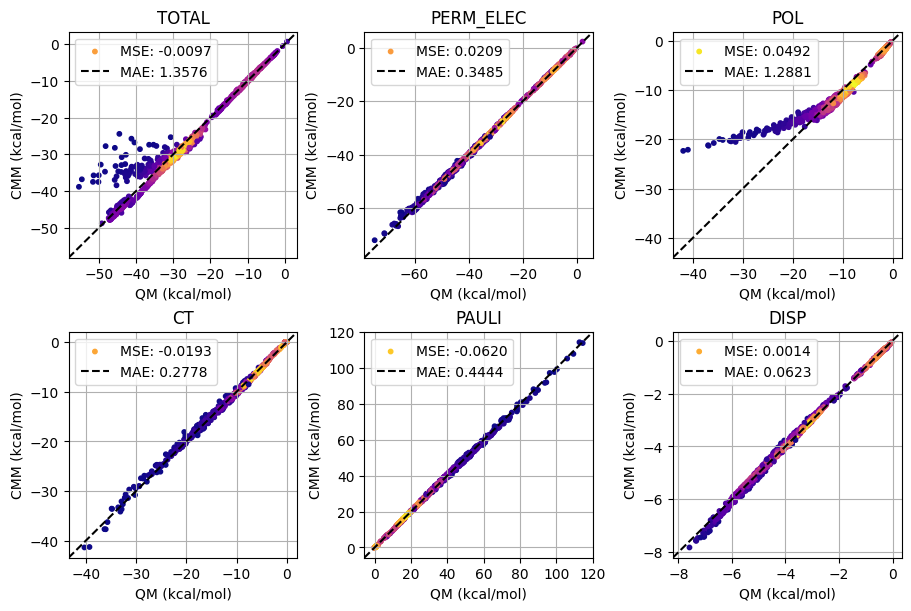

In [448]:
f_water_test_fig = report_eda_cluster(trainer, f_water_test_data)

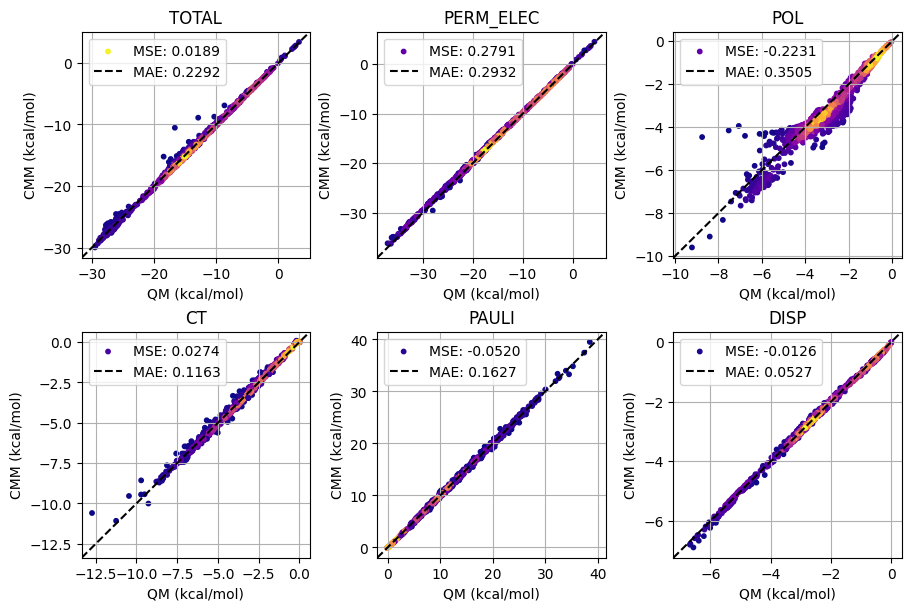

In [ ]:
cl_water_test_fig = report_eda_cluster(trainer, cl_water_test_data)

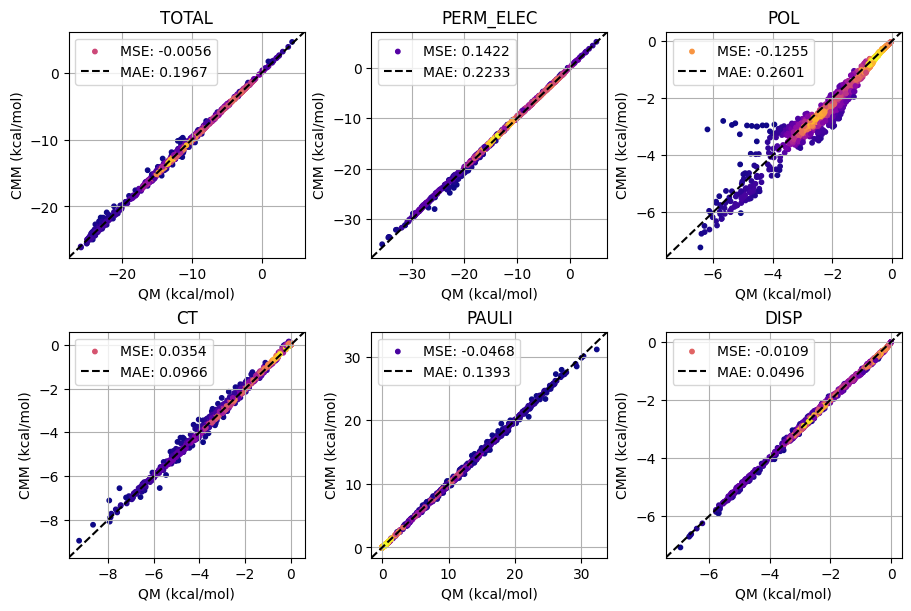

In [ ]:
br_water_test_fig = report_eda_cluster(trainer, br_water_test_data)

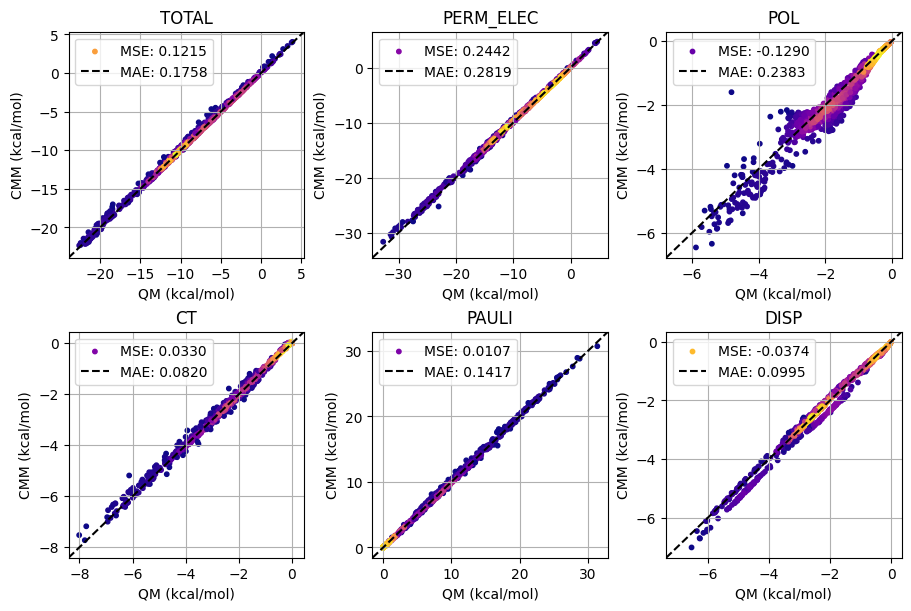

In [ ]:
i_water_test_fig = report_eda_cluster(trainer, i_water_test_data)

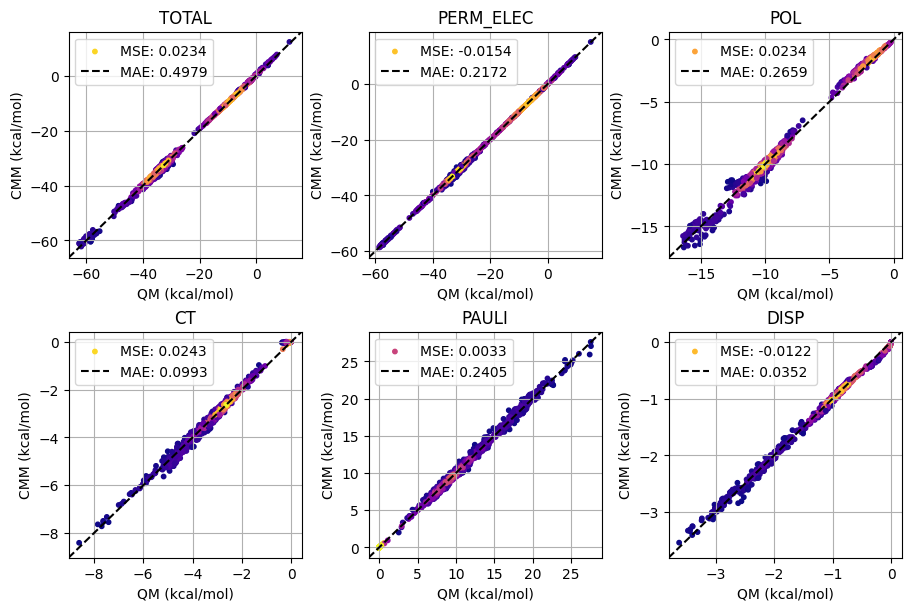

In [ ]:
li_water_test_fig = report_eda_cluster(trainer, li_water_test_data)

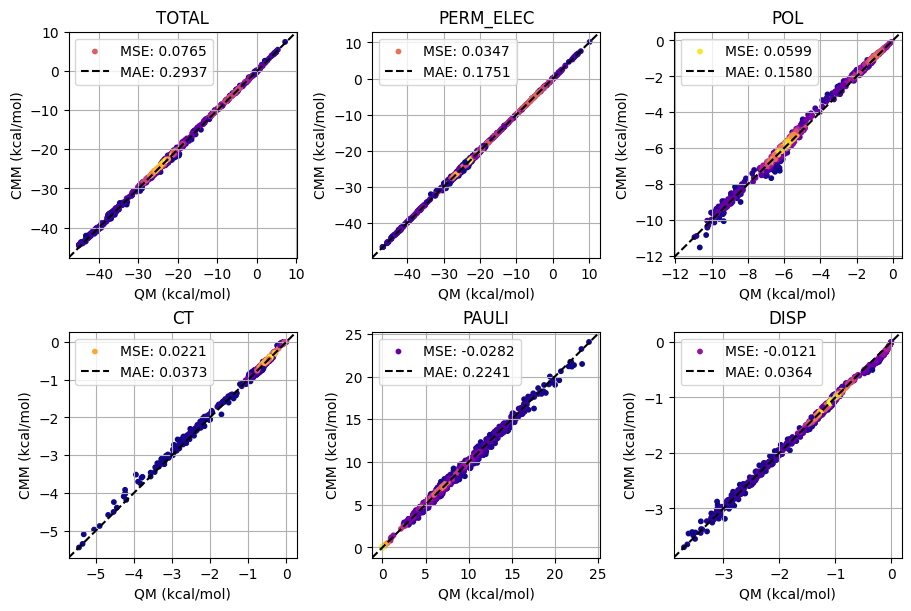

In [ ]:
na_water_test_fig = report_eda_cluster(trainer, na_water_test_data)

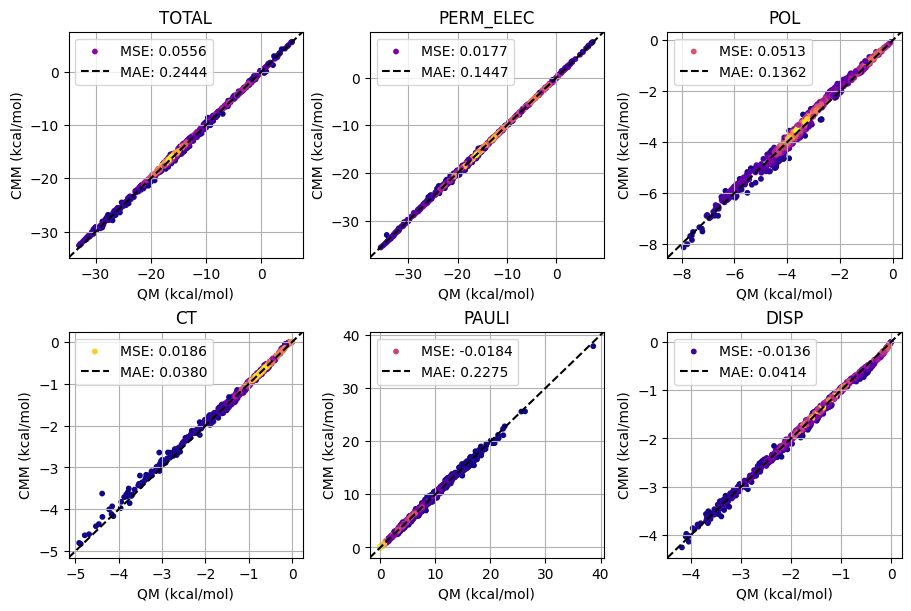

In [ ]:
k_water_test_fig = report_eda_cluster(trainer, k_water_test_data)

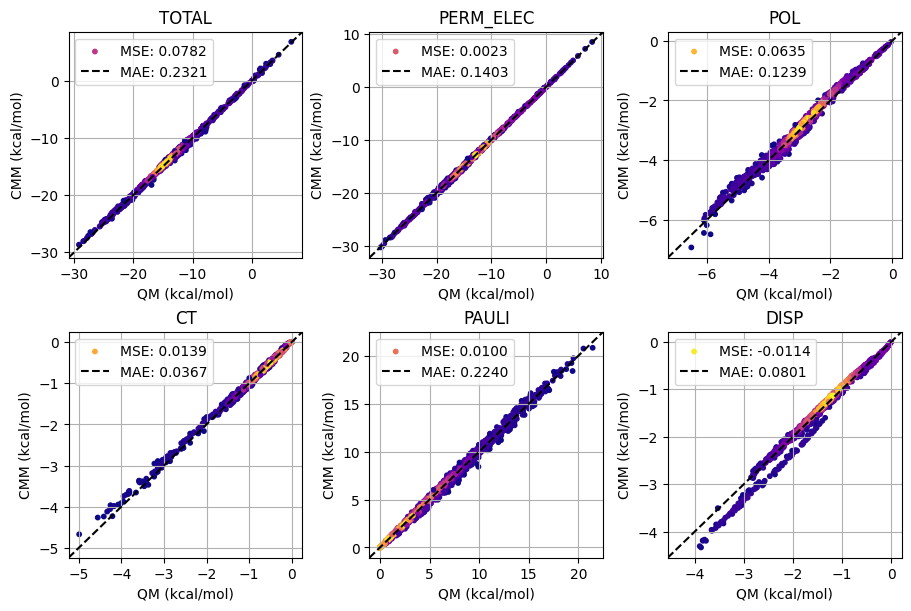

In [ ]:
rb_water_test_fig = report_eda_cluster(trainer, rb_water_test_data)

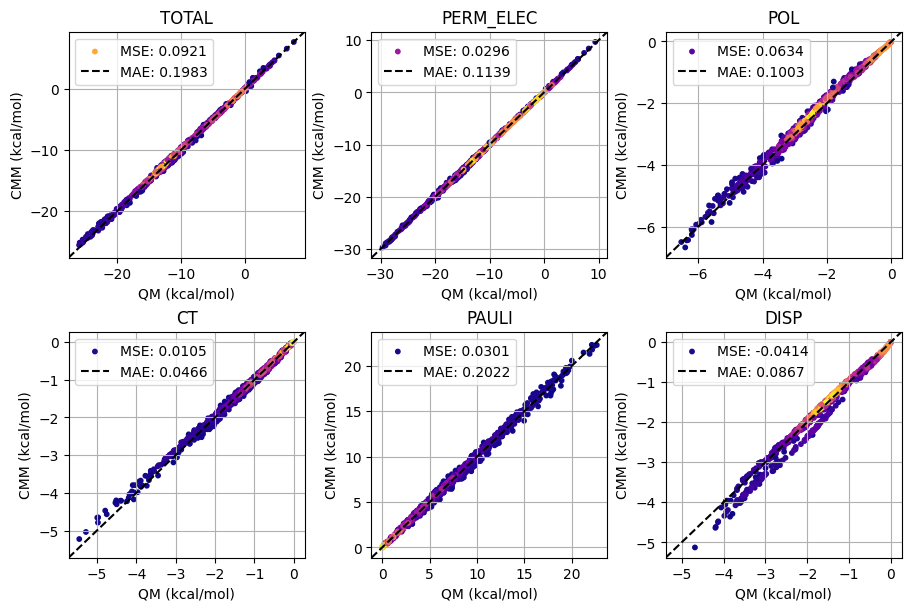

In [ ]:
cs_water_test_fig = report_eda_cluster(trainer, cs_water_test_data)

/home/heindelj/OneDrive/Documents/Coding_Projects/python_development/pyCMM/notebooks/../cmm/forcefield.py:732: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3683.)
  bond_pairs = torch.tensor(bond_pairs, dtype=torch.long).T


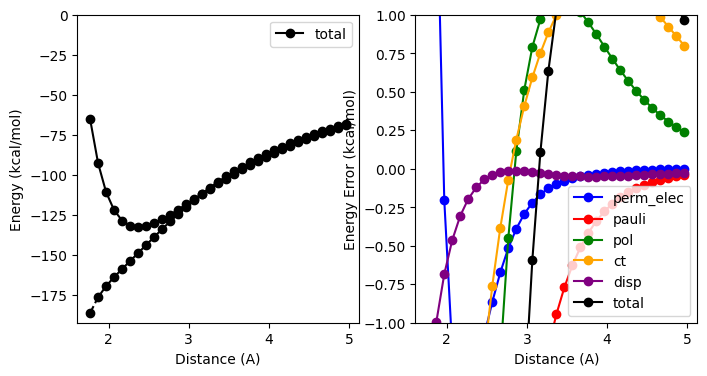

In [ ]:
na_cl_scan_fig = report_eda_scan(trainer, na_cl_scan_data)